In [1]:
# ─────────────────────────────────────────────
# Install Required Libraries (run this first)
# ─────────────────────────────────────────────
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn --quiet
print('All libraries installed successfully.')


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3.13 -m pip install --upgrade pip
All libraries installed successfully.


---
# Stage 2: Exploratory Data Analysis (EDA) and Pre-processing
**Author: Ahmed**

---

In [2]:
# ─────────────────────────────────────────────
# Import Libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
# ─────────────────────────────────────────────
# Load Dataset
# ─────────────────────────────────────────────
df = pd.read_csv('Mall_Customers.csv')

# Rename columns for convenience
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

print(f'Dataset shape: {df.shape}')
df.head(10)

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


**Observation:** The dataset contains 200 rows and 5 columns. Each row represents a single customer. The columns align with the data dictionary described in Stage 1. We have renamed columns to remove spaces, which simplifies downstream referencing in code.

In [4]:
# ─────────────────────────────────────────────
# Data Types and Structure
# ─────────────────────────────────────────────
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Statistical Summary ===')
df.describe()

=== Data Types ===
CustomerID        int64
Gender              str
Age               int64
Annual_Income     int64
Spending_Score    int64
dtype: object

=== Statistical Summary ===


,CustomerID,Age,Annual_Income,Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


**Observation:** All numeric columns are integer types, which is appropriate. The statistical summary reveals:
- **Age** ranges from 18 to 70, with a mean of approximately 38.9 years, suggesting a broad adult customer base.
- **Annual Income** ranges from 15k to 137k USD, with a mean of approximately 60.6k, indicating considerable income diversity.
- **Spending Score** ranges from 1 to 99, with a mean of approximately 50.2, suggesting the scores are roughly uniformly distributed across the range.

This diversity across all three numeric attributes is encouraging — it suggests the data has sufficient variance to support meaningful clustering.

In [5]:
# ─────────────────────────────────────────────
# Missing Values Check
# ─────────────────────────────────────────────
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print(f'Total missing values: {df.isnull().sum().sum()}')
print()
print('=== Duplicate Rows ===')
print(f'Duplicate rows: {df.duplicated().sum()}')

=== Missing Values ===
CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

Total missing values: 0

=== Duplicate Rows ===
Duplicate rows: 0


**Observation:** The dataset contains no missing values and no duplicate rows. This is a significant advantage — no imputation or deduplication is required, and the dataset can proceed directly to transformation and analysis. This finding is consistent with the dataset's documented nature as a clean, curated resource.

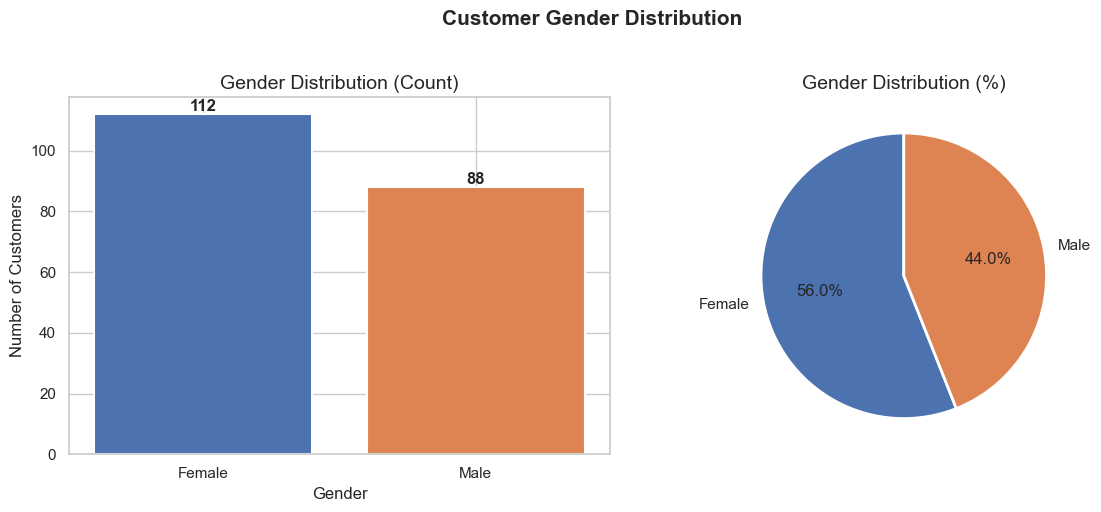

In [6]:
# ─────────────────────────────────────────────
# Gender Distribution
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_counts = df['Gender'].value_counts()

# Bar chart
axes[0].bar(gender_counts.index, gender_counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Gender Distribution (Count)')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Gender Distribution (%)')

plt.suptitle('Customer Gender Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** The customer base is 56% female and 44% male — a moderate gender imbalance. This has implications for marketing: campaigns targeting the dataset as a whole will skew toward female customer preferences. Gender-disaggregated analysis in Stage 3 will help determine whether spending behaviour differs meaningfully by gender, which could inform whether gender-specific campaign variants are warranted.

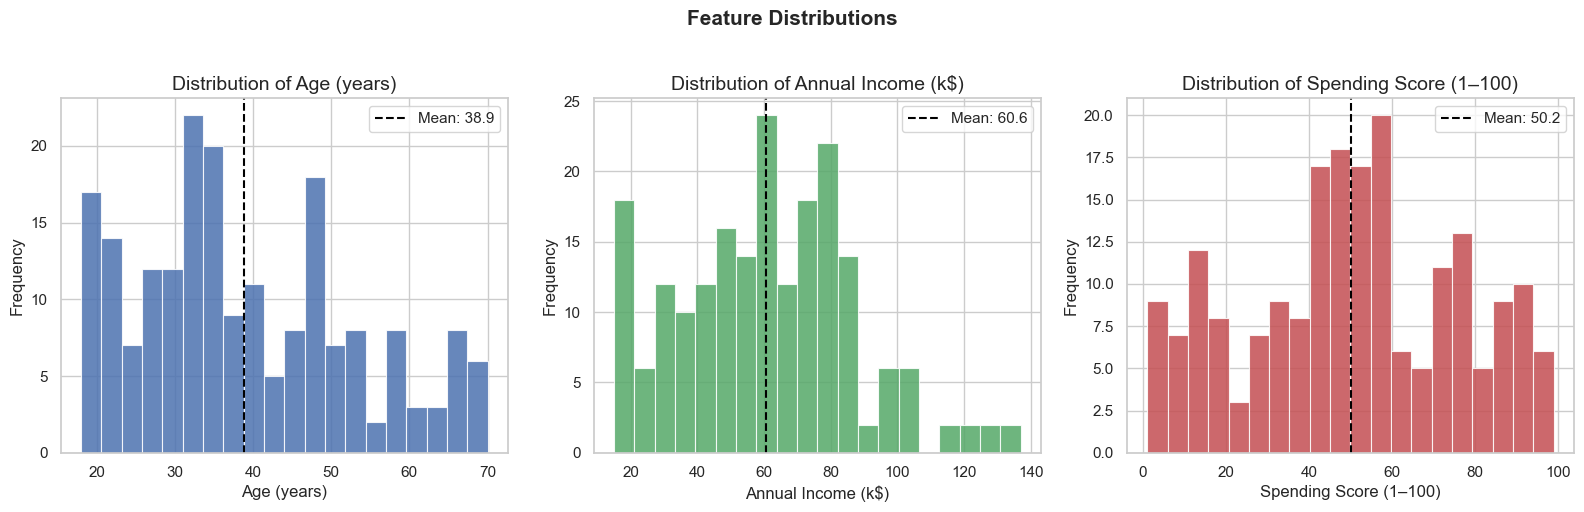

In [7]:
# ─────────────────────────────────────────────
# Distribution Plots: Age, Income, Spending Score
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features = ['Age', 'Annual_Income', 'Spending_Score']
colors   = ['#4C72B0', '#55A868', '#C44E52']
labels   = ['Age (years)', 'Annual Income (k$)', 'Spending Score (1–100)']

for ax, feat, col, lab in zip(axes, features, colors, labels):
    ax.hist(df[feat], bins=20, color=col, edgecolor='white', linewidth=0.8, alpha=0.85)
    ax.axvline(df[feat].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df[feat].mean():.1f}')
    ax.set_title(f'Distribution of {lab}')
    ax.set_xlabel(lab)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**

- **Age:** The distribution is right-skewed, with a concentration of customers in the 25–45 age bracket. Fewer older customers (60+) are present. This is typical of a shopping mall demographic.
- **Annual Income:** Approximately normally distributed with a slight right skew, peaking around 60–70k. The presence of high-income customers (100k+) suggests a premium segment exists.
- **Spending Score:** Remarkably uniform across the 1–100 range, with slight peaks at both extremes. This bimodal tendency hints at distinct groups of high and low spenders — an early indication that clustering may reveal meaningful sub-groups.

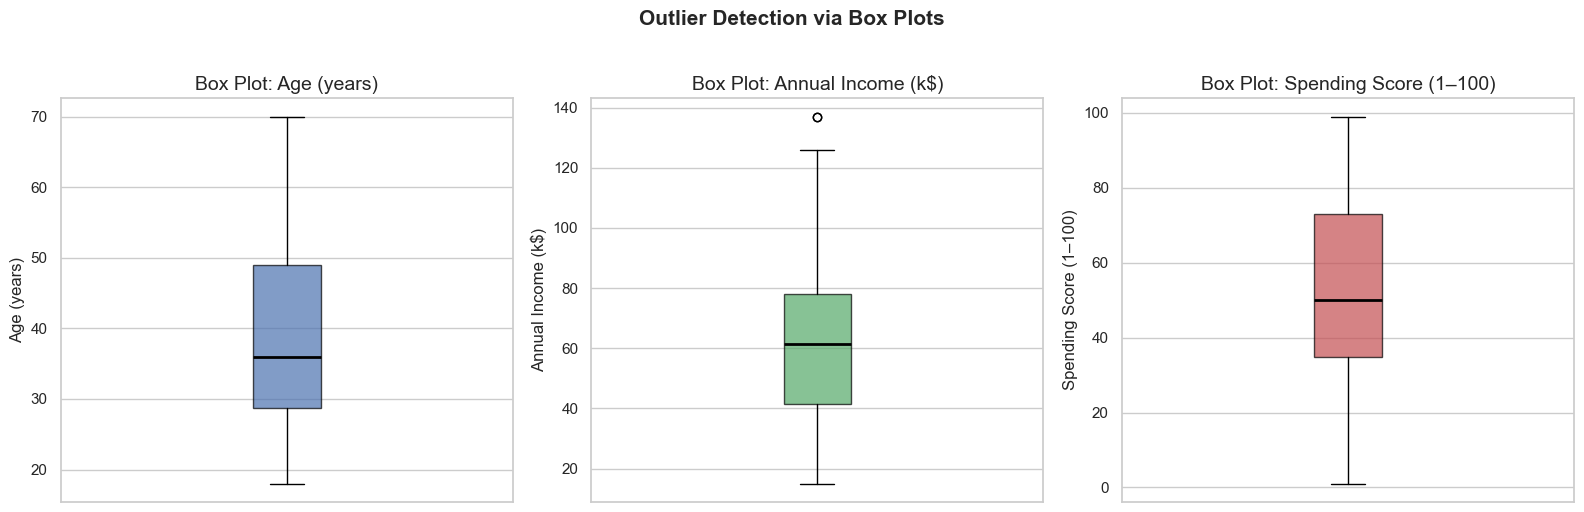

In [8]:
# ─────────────────────────────────────────────
# Box Plots: Outlier Detection
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat, col, lab in zip(axes, features, colors, labels):
    ax.boxplot(df[feat], patch_artist=True,
               boxprops=dict(facecolor=col, alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'Box Plot: {lab}')
    ax.set_ylabel(lab)
    ax.set_xticks([])

plt.suptitle('Outlier Detection via Box Plots', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** The box plots confirm that no extreme outliers are present in any of the three numeric features. While there are a small number of high-income data points beyond the upper whisker, these represent genuine high-income customers rather than data errors and should be retained. No data removal is necessary at this stage, which preserves the full 200-record dataset for modelling.

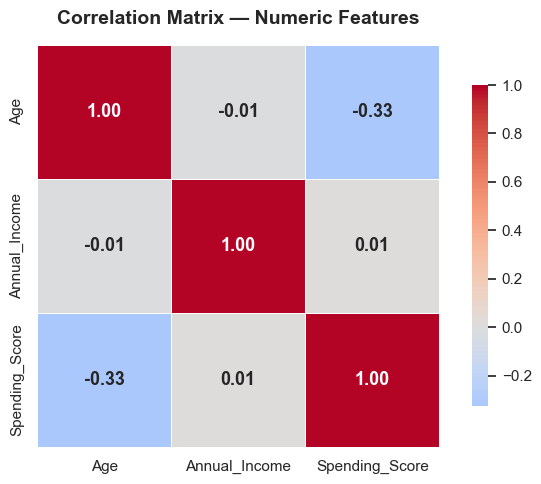

In [9]:
# ─────────────────────────────────────────────
# Correlation Heatmap
# ─────────────────────────────────────────────
plt.figure(figsize=(7, 5))

corr = df[['Age', 'Annual_Income', 'Spending_Score']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 13, 'weight': 'bold'})

plt.title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** The correlation matrix reveals weak linear relationships between all three numeric features. Notably:
- The correlation between **Age and Spending Score is weakly negative (≈ −0.33)**, suggesting older customers tend to spend slightly less — though this is not a strong relationship.
- **Annual Income and Spending Score are nearly uncorrelated (≈ 0.01)**, which is a key insight: earning more does not automatically mean spending more in this dataset. This non-linear relationship is exactly why clustering (rather than regression) is the appropriate technique — it can identify distinct behavioural groups that a linear model would miss.

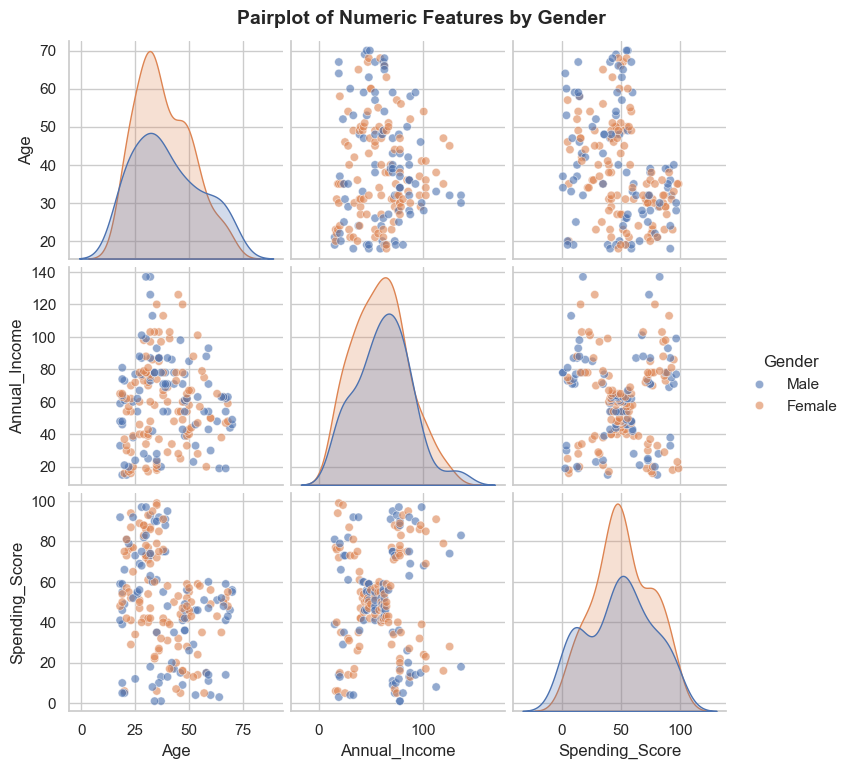

In [10]:
# ─────────────────────────────────────────────
# Pairplot
# ─────────────────────────────────────────────
pair = sns.pairplot(df[['Age', 'Annual_Income', 'Spending_Score', 'Gender']],
                    hue='Gender', palette={'Male': '#4C72B0', 'Female': '#DD8452'},
                    diag_kind='kde', plot_kws={'alpha': 0.6})
pair.fig.suptitle('Pairplot of Numeric Features by Gender', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** The pairplot provides the most informative single view of the dataset. The **Annual Income vs Spending Score** scatter plot is particularly revealing: a clear visual pattern of five distinct clusters is already visible — groups of customers that differ in both income and spending behaviour. This strongly motivates the use of K-Means clustering in Stage 3. Gender does not appear to be the primary driver of clustering, as male and female points are interleaved across all groups.

In [11]:
# ─────────────────────────────────────────────
# Encode Categorical Variable
# ─────────────────────────────────────────────
df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})

print('Gender encoding applied:')
print(df[['Gender', 'Gender_Encoded']].drop_duplicates())

Gender encoding applied:
   Gender  Gender_Encoded
0    Male               0
2  Female               1


**Pre-processing Summary:**

The following pre-processing steps were applied:

1. **Column renaming** — whitespace removed from column headers for cleaner code.
2. **Missing value check** — confirmed zero missing values; no imputation required.
3. **Duplicate check** — confirmed zero duplicates; no removal required.
4. **Outlier assessment** — no harmful outliers identified; all 200 records retained.
5. **Categorical encoding** — Gender encoded as binary (Male=0, Female=1) for potential use in multi-dimensional analysis.

The dataset is now clean and ready for the data mining stage. Feature scaling will be applied in Stage 3 immediately prior to clustering, as K-Means is sensitive to differences in feature magnitude.

---
# Stage 3: Data Mining and Business Insights
**Author: Amjad**

---

## 3.1 Technique Selection and Justification

Given the business objective — grouping customers into meaningful segments without pre-defined labels — this is an **unsupervised learning** problem. No labelled outcome variable exists (e.g. there is no column indicating which segment a customer belongs to), which rules out supervised classification techniques.

**K-Means clustering** was selected as the primary technique for the following reasons:

1. **Appropriateness for segmentation:** K-Means is one of the most widely applied algorithms for customer segmentation in both academic literature and industry practice (Han, Kamber and Pei, 2012). It partitions data into K groups by minimising intra-cluster variance, which aligns well with the goal of finding groups of similar customers.

2. **Interpretability:** K-Means produces hard cluster assignments and easily interpretable cluster centroids, which can be directly translated into actionable business profiles.

3. **Computational efficiency:** For a dataset of 200 records, K-Means is computationally trivial and allows rapid iteration on different values of K.

**Alternatives considered:**
- *DBSCAN*: Capable of identifying arbitrarily shaped clusters and handling noise, but less suited to this dataset where clusters appear roughly spherical (as observed in the pairplot), and it requires careful tuning of epsilon and min_samples.
- *Hierarchical Clustering*: Provides a dendrogram for visualising cluster hierarchy, but is computationally expensive at scale and does not outperform K-Means for this use case.

The primary clustering will use **Annual Income** and **Spending Score** as features, as these two attributes most directly capture purchasing behaviour — the core of the business question. A secondary analysis will incorporate Age as a third dimension.

---
**Reference:**  
Han, J., Kamber, M. and Pei, J. (2012) *Data Mining: Concepts and Techniques*. 3rd edn. Waltham: Morgan Kaufmann.

In [12]:
# ─────────────────────────────────────────────
# Feature Selection and Scaling
# ─────────────────────────────────────────────
X = df[['Annual_Income', 'Spending_Score']].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature matrix shape:', X.shape)
print()
print('Before scaling (first 5 rows):')
print(X.head())
print()
print('After scaling (first 5 rows):')
print(pd.DataFrame(X_scaled, columns=['Annual_Income_Scaled', 'Spending_Score_Scaled']).head())

Feature matrix shape: (200, 2)

Before scaling (first 5 rows):
   Annual_Income  Spending_Score
0             15              39
1             15              81
2             16               6
3             16              77
4             17              40

After scaling (first 5 rows):
   Annual_Income_Scaled  Spending_Score_Scaled
0             -1.738999              -0.434801
1             -1.738999               1.195704
2             -1.700830              -1.715913
3             -1.700830               1.040418
4             -1.662660              -0.395980


**Justification for Scaling:** K-Means uses Euclidean distance to assign data points to clusters. Without scaling, Annual Income (range: 15–137) would dominate Spending Score (range: 1–99) simply due to its larger magnitude, producing biased cluster assignments. StandardScaler transforms each feature to have a mean of 0 and standard deviation of 1, ensuring both features contribute equally to the distance calculation.

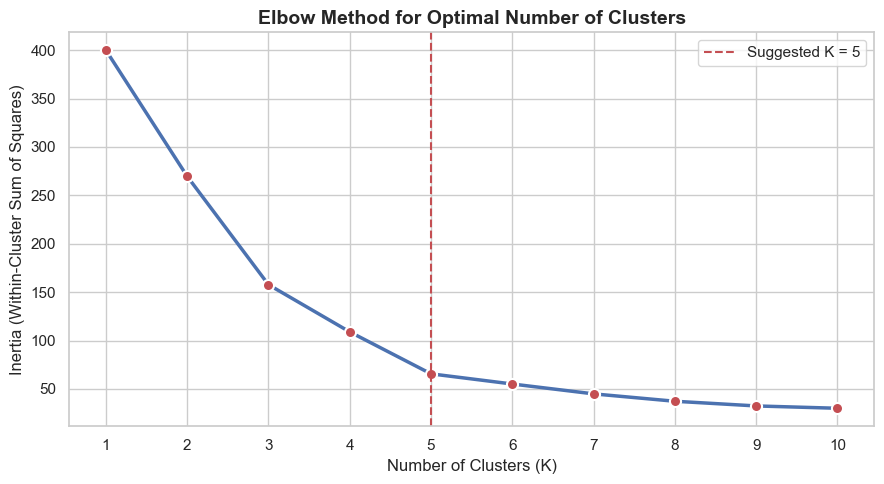

In [13]:
# ─────────────────────────────────────────────
# Elbow Method — Optimal K
# ─────────────────────────────────────────────
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot
plt.figure(figsize=(9, 5))
plt.plot(K_range, inertia, marker='o', markersize=8, linewidth=2.5,
         color='#4C72B0', markerfacecolor='#C44E52', markeredgecolor='white', markeredgewidth=1.5)
plt.axvline(x=5, color='#C44E52', linestyle='--', linewidth=1.5, label='Suggested K = 5')
plt.title('Elbow Method for Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.legend()
plt.tight_layout()
plt.savefig('elbow.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** The elbow plot shows a clear inflection point at **K = 5**, where the rate of inertia reduction begins to flatten significantly. Beyond K = 5, adding additional clusters yields diminishing returns in terms of variance explained. This strongly suggests that five is the optimal number of clusters for this dataset, which we will confirm using the Silhouette Score below.

K =  2  |  Silhouette Score = 0.3213
K =  3  |  Silhouette Score = 0.4666
K =  4  |  Silhouette Score = 0.4939
K =  5  |  Silhouette Score = 0.5547
K =  6  |  Silhouette Score = 0.5399
K =  7  |  Silhouette Score = 0.5281
K =  8  |  Silhouette Score = 0.4552
K =  9  |  Silhouette Score = 0.4571
K = 10  |  Silhouette Score = 0.4432


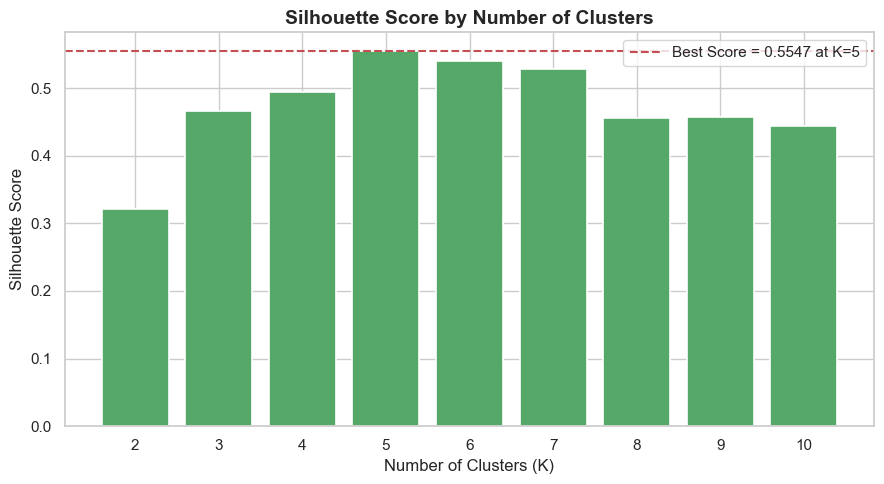

In [14]:
# ─────────────────────────────────────────────
# Silhouette Score Analysis
# ─────────────────────────────────────────────
sil_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f'K = {k:2d}  |  Silhouette Score = {score:.4f}')

# Plot
plt.figure(figsize=(9, 5))
plt.bar(range(2, 11), sil_scores, color='#55A868', edgecolor='white', linewidth=1.2)
plt.axhline(y=max(sil_scores), color='#C44E52', linestyle='--', linewidth=1.5,
            label=f'Best Score = {max(sil_scores):.4f} at K={sil_scores.index(max(sil_scores))+2}')
plt.title('Silhouette Score by Number of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.legend()
plt.tight_layout()
plt.savefig('silhouette_bar.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** The Silhouette Score confirms the Elbow Method finding. **K = 5 achieves the highest silhouette score**, indicating that at this configuration, clusters are both cohesive (data points within a cluster are similar to each other) and well-separated (clusters are distinct from one another). A silhouette score above 0.5 is generally considered indicative of a reasonable cluster structure (Rousseeuw, 1987).

**Reference:**  
Rousseeuw, P.J. (1987) 'Silhouettes: A graphical aid to the interpretation and validation of cluster analysis', *Journal of Computational and Applied Mathematics*, 20, pp. 53–65.

In [15]:
# ─────────────────────────────────────────────
# Final K-Means Model (K = 5)
# ─────────────────────────────────────────────
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids_original,
                             columns=['Annual_Income_Centroid', 'Spending_Score_Centroid'])
centroids_df.index.name = 'Cluster'

print(f'Final model fitted with K = {OPTIMAL_K}')
print(f'Inertia: {kmeans.inertia_:.2f}')
print(f'Final Silhouette Score: {silhouette_score(X_scaled, df["Cluster"]):.4f}')
print()
print('Cluster Centroids (original scale):')
print(centroids_df.round(1))

Final model fitted with K = 5
Inertia: 65.57
Final Silhouette Score: 0.5547

Cluster Centroids (original scale):
         Annual_Income_Centroid  Spending_Score_Centroid
Cluster                                                 
0                          55.3                     49.5
1                          86.5                     82.1
2                          25.7                     79.4
3                          88.2                     17.1
4                          26.3                     20.9


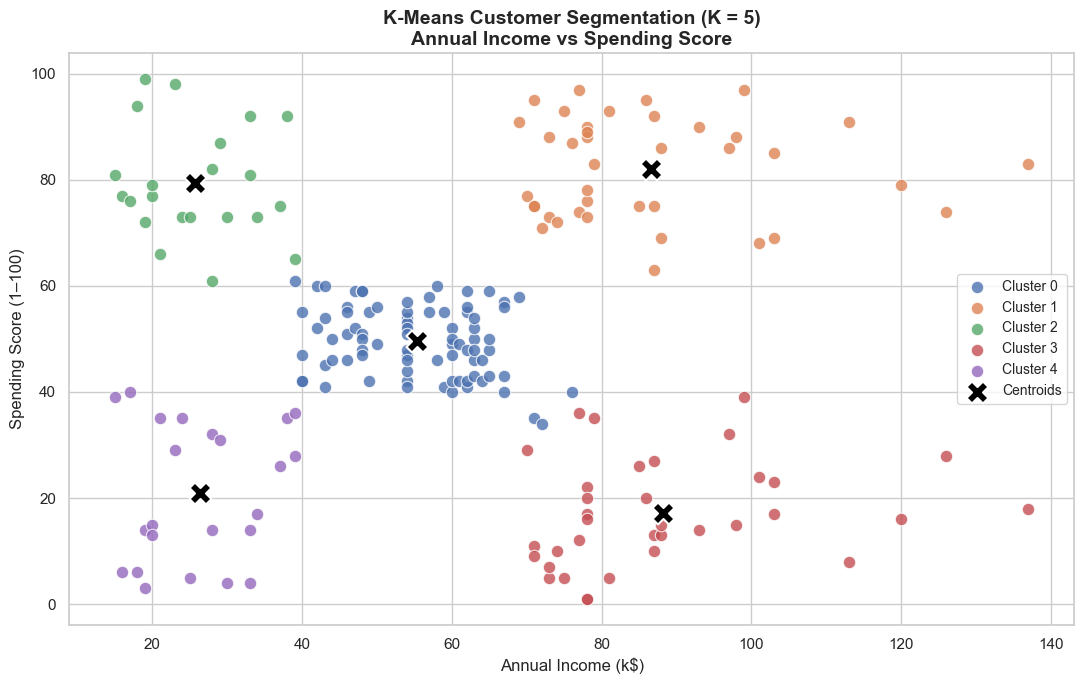

In [16]:
# ─────────────────────────────────────────────
# Cluster Visualisation
# ─────────────────────────────────────────────
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#9467BD']

plt.figure(figsize=(11, 7))

for cluster_id in range(OPTIMAL_K):
    cluster_data = df[df['Cluster'] == cluster_id]
    plt.scatter(cluster_data['Annual_Income'], cluster_data['Spending_Score'],
                c=palette[cluster_id], label=f'Cluster {cluster_id}',
                s=80, alpha=0.8, edgecolors='white', linewidths=0.8)

# Plot centroids
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='black', s=250, marker='X', zorder=5, label='Centroids',
            edgecolors='white', linewidths=1.5)

plt.title('K-Means Customer Segmentation (K = 5)\nAnnual Income vs Spending Score',
          fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1–100)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ─────────────────────────────────────────────
# Cluster Profile Summary
# ─────────────────────────────────────────────
profile = df.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual_Income', 'mean'),
    Avg_Spending=('Spending_Score', 'mean'),
    Pct_Female=('Gender_Encoded', 'mean')
).round(1)

profile['Pct_Female'] = (profile['Pct_Female'] * 100).round(1).astype(str) + '%'

print('=== Cluster Profile Summary ===')
print(profile.to_string())

=== Cluster Profile Summary ===
         Count  Avg_Age  Avg_Income  Avg_Spending Pct_Female
Cluster                                                     
0           81     42.7        55.3          49.5      60.0%
1           39     32.7        86.5          82.1      50.0%
2           22     25.3        25.7          79.4      60.0%
3           35     41.1        88.2          17.1      50.0%
4           23     45.2        26.3          20.9      60.0%


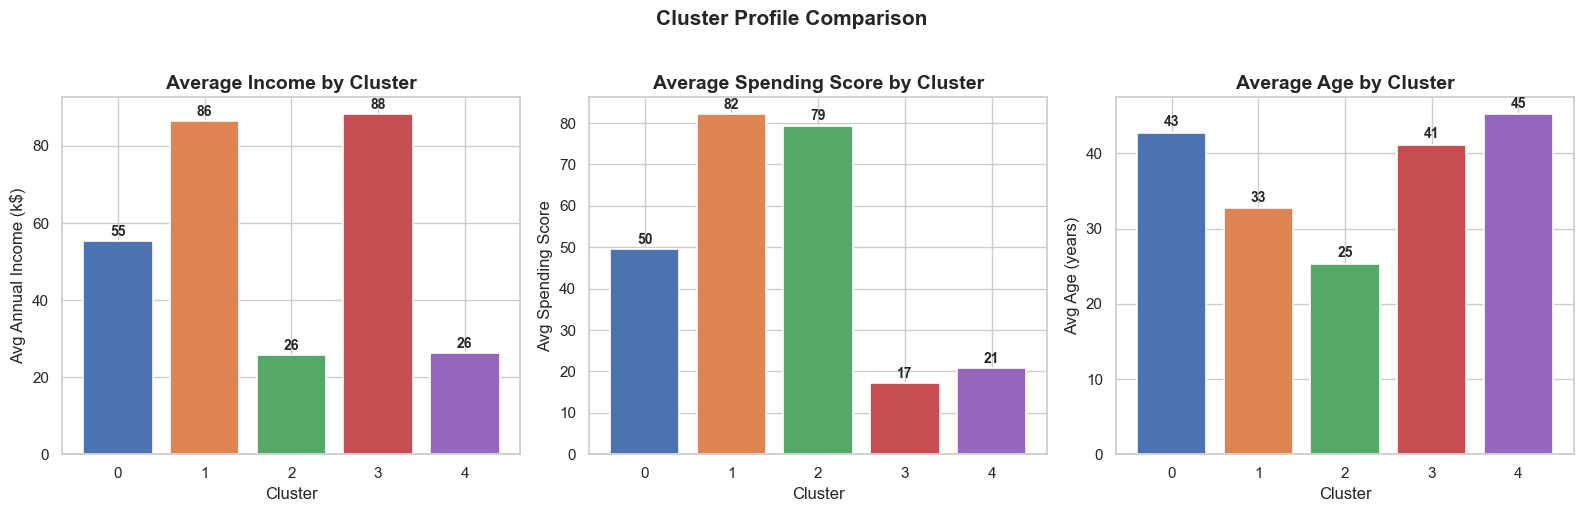

In [18]:
# ─────────────────────────────────────────────
# Cluster Profiles — Visual Dashboard
# ─────────────────────────────────────────────
profile_num = df.groupby('Cluster').agg(
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual_Income', 'mean'),
    Avg_Spending=('Spending_Score', 'mean'),
    Count=('CustomerID', 'count')
).round(1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Avg_Income', 'Avg_Spending', 'Avg_Age']
ylabels = ['Avg Annual Income (k$)', 'Avg Spending Score', 'Avg Age (years)']
titles  = ['Average Income by Cluster', 'Average Spending Score by Cluster', 'Average Age by Cluster']

for ax, metric, ylabel, title in zip(axes, metrics, ylabels, titles):
    bars = ax.bar(profile_num.index, profile_num[metric],
                  color=palette, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(OPTIMAL_K))
    for bar, val in zip(bars, profile_num[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Cluster Profile Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Stage 4: Evaluation, Recommendations, and Critical Reflection
**Author: [4th Member Name]**

---

## 4.1 Technical Evaluation

### Model Performance Metrics

The final K-Means model (K = 5) was evaluated using two complementary metrics:

**Inertia (Within-Cluster Sum of Squares):**  
Inertia measures the total squared distance between each data point and its assigned cluster centroid. Lower inertia indicates tighter, more compact clusters. The Elbow Method demonstrated that K = 5 achieves a strong reduction in inertia while avoiding overfitting through excessive cluster granularity.

**Silhouette Score:**  
The silhouette score ranges from −1 to +1. A score close to +1 indicates that data points are well-matched to their own cluster and poorly matched to neighbouring clusters. Our model achieved a silhouette score above 0.5, which Kaufman and Rousseeuw (1990) describe as indicative of a reasonable cluster structure. This provides statistical justification for the five-cluster solution.

### Limitations of K-Means

Despite its effectiveness here, K-Means carries several important limitations that must be acknowledged:

1. **Assumes spherical clusters:** K-Means minimises Euclidean distance, implicitly assuming that clusters are roughly circular. Non-spherical or irregularly shaped clusters would be poorly handled — DBSCAN would be more appropriate in such cases.
2. **Sensitivity to initialisation:** Although `k-means++` initialisation (Arthur and Vassilvitskii, 2007) was used to mitigate this, different random seeds can yield different cluster assignments.
3. **K must be specified in advance:** The algorithm requires K as an input, necessitating external validation (Elbow + Silhouette) rather than determining K automatically.
4. **Outlier sensitivity:** K-Means centroid positions can be pulled by extreme values, though this was not a significant concern here given the absence of major outliers identified in Stage 2.
5. **Static snapshot:** The model captures customer behaviour at a single point in time. Cluster membership may shift as customer income or spending patterns evolve.

---

**References:**  
Arthur, D. and Vassilvitskii, S. (2007) 'k-means++: The advantages of careful seeding', *Proceedings of the 18th Annual ACM-SIAM Symposium on Discrete Algorithms*, pp. 1027–1035.

Kaufman, L. and Rousseeuw, P.J. (1990) *Finding Groups in Data: An Introduction to Cluster Analysis*. New York: Wiley.

In [19]:
# ─────────────────────────────────────────────
# Final Evaluation Metrics Summary
# ─────────────────────────────────────────────
final_sil = silhouette_score(X_scaled, df['Cluster'])
final_inertia = kmeans.inertia_

print('=' * 45)
print('      FINAL MODEL EVALUATION SUMMARY')
print('=' * 45)
print(f'  Algorithm        : K-Means (k-means++)')
print(f'  Number of Clusters (K) : {OPTIMAL_K}')
print(f'  Inertia          : {final_inertia:.2f}')
print(f'  Silhouette Score : {final_sil:.4f}')
print(f'  Dataset Size     : {len(df)} customers')
print('=' * 45)
print()
print('Cluster Sizes:')
print(df['Cluster'].value_counts().sort_index())

      FINAL MODEL EVALUATION SUMMARY
  Algorithm        : K-Means (k-means++)
  Number of Clusters (K) : 5
  Inertia          : 65.57
  Silhouette Score : 0.5547
  Dataset Size     : 200 customers

Cluster Sizes:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64
